# MATH 210 Introduction to Mathematical Computing

**April 10, 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import pandas as pd

In [2]:
data = pd.read_csv("tidal_data.csv")
y = data.iloc[:,1]

In [13]:
N = len(y)
print(N)

10079


In [14]:
N/60/24

6.999305555555555

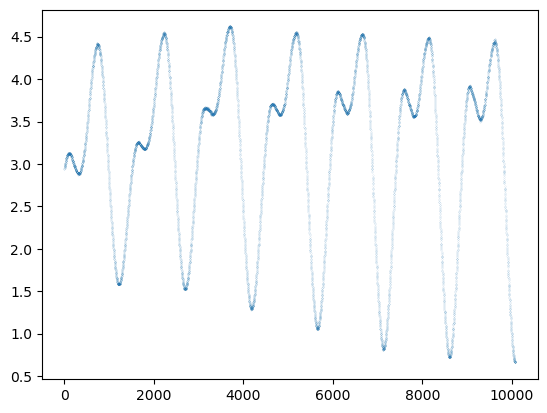

In [15]:
plt.plot(y,'.',ms=0.1)
plt.show()

$$
f(x) = c_0 + c_1 \sin \left( \frac{2 \pi (7) x}{N} \right) + c_2 \cos \left( \frac{2 \pi (7) x}{N} \right)
 + c_3 \sin \left( \frac{2 \pi (14) x}{N} \right) + c_4 \cos \left( \frac{2 \pi (14) x}{N} \right)
$$

In [16]:
x = np.linspace(0,N,N)
f0 = np.ones(N)
f1 = np.sin(2*np.pi*7*x/N)
f2 = np.cos(2*np.pi*7*x/N)
f3 = np.sin(2*np.pi*14*x/N)
f4 = np.cos(2*np.pi*14*x/N)
A = np.column_stack([f0,f1,f2,f3,f4])
c = la.solve(A.T@A,A.T@y)
print(c)

[ 3.12469819  0.26478381 -1.19684144  0.54109744 -0.20616934]


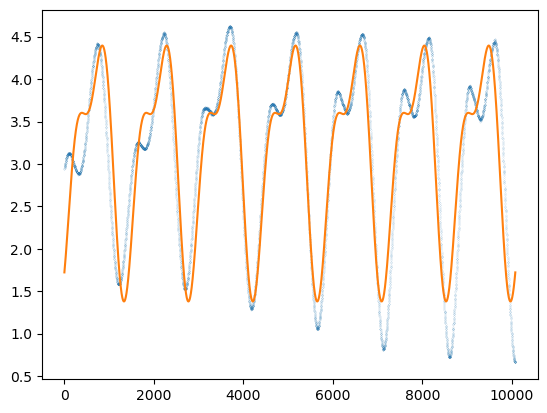

In [17]:
f = c[0]*f0 + c[1]*f1 + c[2]*f2 + c[3]*f3 + c[4]*f4
plt.plot(x,y,'.',ms=0.1)
plt.plot(x,f)
plt.show()

## Power Method

In [24]:
A = np.array([[1.,2.],[2.,1.]])
V,P = la.eig(A)

In [25]:
print(V.real)

[ 3. -1.]


In [26]:
print(P)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [27]:
x = np.array([[1.],[0.]])
for k in range(5):
    x = A@x
    print(x,'\n')

[[1.]
 [2.]] 

[[5.]
 [4.]] 

[[13.]
 [14.]] 

[[41.]
 [40.]] 

[[121.]
 [122.]] 



In [28]:
x = np.array([[1.],[0.]])
for k in range(5):
    x = A@x
    x = x/np.max(np.abs(x))
    print(x,'\n')

[[0.5]
 [1. ]] 

[[1. ]
 [0.8]] 

[[0.92857143]
 [1.        ]] 

[[1.        ]
 [0.97560976]] 

[[0.99180328]
 [1.        ]] 



In [29]:
eval1 = np.sum(x*(A@x))/np.sum(x*x)
print(eval1)

2.9999322607959353


In [30]:
A = np.array([[1.,1.,0.],[1.,1.,1.,],[0.,1.,1.]])
x = np.array([[1.],[0.],[0.]])
for k in range(10):
    x = A@x
    x = x/np.max(np.abs(x))
print(x,'\n')
eval1 = np.sum(x*(A@x))/np.sum(x*x)
print(eval1)

[[0.70731707]
 [1.        ]
 [0.70689655]] 

2.414213499851323


In [31]:
V,P = la.eig(A)

In [32]:
P[:,2]

array([0.5       , 0.70710678, 0.5       ])

In [33]:
V

array([-0.41421356+0.j,  1.        +0.j,  2.41421356+0.j])